# Diagnóstico por imagem com CNN (IDC)

Este notebook apresenta uma pipeline completa para classificação binária de imagens histopatológicas de carcinoma ductal invasivo (IDC):

- **Classe 0**: negativo
- **Classe 1**: positivo

## Objetivos
1. Realizar análise exploratória das imagens.
2. Preparar dados com split de treino, validação e teste.
3. Treinar um modelo de rede neural convolucional (CNN).
4. Avaliar desempenho com métricas e matriz de confusão.
5. Interpretar resultados para uso no projeto.

## Resumo técnico do problema

### Variável alvo (target)
O target do modelo é binário e representa a presença de carcinoma ductal invasivo (IDC):
- `0`: negativo
- `1`: positivo

### Objetivo de modelagem
Construir um classificador de imagens histopatológicas que estime a probabilidade de IDC para **apoio à decisão clínica**, priorizando sensibilidade para reduzir risco de falso negativo.

### Critério clínico de interpretação
Como erros de falso negativo podem atrasar condutas importantes, além de `accuracy`, focamos em `recall`, `F1-score`, `AUC` e análise de threshold para ajustar trade-off entre sensibilidade e precisão.

## 1) Importações, configurações e paths

In [7]:
from pathlib import Path
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
CLASS0_DIR = DATA_DIR / "0"
CLASS1_DIR = DATA_DIR / "1"

if not CLASS0_DIR.exists() or not CLASS1_DIR.exists():
    raise FileNotFoundError(f"Pastas de classe não encontradas em: {DATA_DIR}")

IMG_SIZE = (128, 128)
BATCH_SIZE = 16
EPOCHS = 20
LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Projeto: {PROJECT_ROOT}")
print(f"Dados: {DATA_DIR}")
print(f"Device: {DEVICE}")

Projeto: c:\Users\Kelvin\Downloads\Tech-Challenge-FIAP-main\Tech-Challenge-FIAP-main
Dados: c:\Users\Kelvin\Downloads\Tech-Challenge-FIAP-main\Tech-Challenge-FIAP-main\data
Device: cpu


## 2) Análise exploratória das imagens

Nesta etapa levantamos:
- quantidade por classe
- distribuição (balanceamento)
- inspeção visual de amostras

Total de imagens: 100
Classe 0 (negativo): 50
Classe 1 (positivo): 50
Proporção classe 1: 50.00%


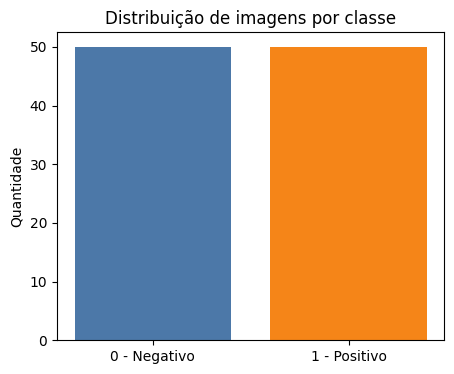

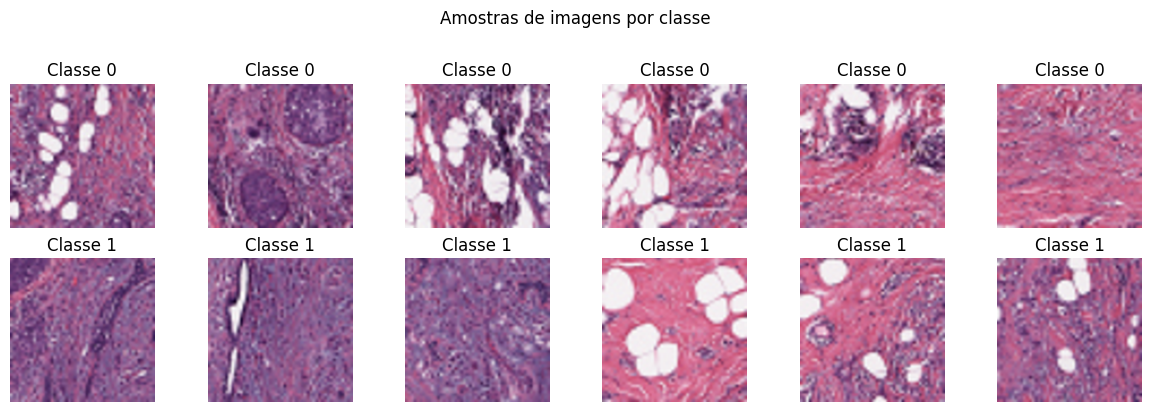

In [8]:
files_0 = sorted([p for p in CLASS0_DIR.iterdir() if p.is_file()])
files_1 = sorted([p for p in CLASS1_DIR.iterdir() if p.is_file()])

count_0 = len(files_0)
count_1 = len(files_1)
total = count_0 + count_1

print(f"Total de imagens: {total}")
print(f"Classe 0 (negativo): {count_0}")
print(f"Classe 1 (positivo): {count_1}")
print(f"Proporção classe 1: {count_1/total:.2%}")

# Gráfico de distribuição por classe
plt.figure(figsize=(5, 4))
plt.bar(["0 - Negativo", "1 - Positivo"], [count_0, count_1], color=["#4C78A8", "#F58518"])
plt.title("Distribuição de imagens por classe")
plt.ylabel("Quantidade")
plt.show()

# Inspeção visual de amostras por classe
sample_0 = files_0[:6]
sample_1 = files_1[:6]

plt.figure(figsize=(12, 4))
for i, f in enumerate(sample_0 + sample_1):
    img = Image.open(f).convert("RGB").resize(IMG_SIZE)
    ax = plt.subplot(2, 6, i + 1)
    plt.imshow(img)
    label = 0 if i < 6 else 1
    plt.title(f"Classe {label}")
    plt.axis("off")
plt.suptitle("Amostras de imagens por classe", y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# Analise quantitativa simples das imagens por classe
# (suporte para discutir qualidade de dados e separabilidade inicial)

def summarize_image_set(paths, max_images=300):
    sample = paths[: min(len(paths), max_images)]
    means = []
    stds = []
    sizes = []
    for p in sample:
        arr = np.array(Image.open(p).convert("RGB"), dtype=np.float32) / 255.0
        means.append(arr.mean(axis=(0, 1)))
        stds.append(arr.std(axis=(0, 1)))
        sizes.append(arr.shape[:2])
    means = np.array(means)
    stds = np.array(stds)
    h = np.array([s[0] for s in sizes])
    w = np.array([s[1] for s in sizes])
    return {
        "n_amostra": len(sample),
        "mean_rgb": means.mean(axis=0),
        "std_rgb": stds.mean(axis=0),
        "altura_media": h.mean(),
        "largura_media": w.mean(),
    }

stats_0 = summarize_image_set(files_0)
stats_1 = summarize_image_set(files_1)

print("Resumo classe 0 (negativo):", stats_0)
print("Resumo classe 1 (positivo):", stats_1)

Resumo classe 0 (negativo): {'n_amostra': 50, 'mean_rgb': array([0.75445724, 0.54379153, 0.6653786 ], dtype=float32), 'std_rgb': array([0.1136514 , 0.1686801 , 0.12674817], dtype=float32), 'altura_media': np.float64(50.0), 'largura_media': np.float64(50.0)}
Resumo classe 1 (positivo): {'n_amostra': 50, 'mean_rgb': array([0.60385424, 0.39156318, 0.566295  ], dtype=float32), 'std_rgb': array([0.10088093, 0.11827394, 0.09082627], dtype=float32), 'altura_media': np.float64(50.0), 'largura_media': np.float64(50.0)}


### O que levantamos na análise das imagens

- Verificamos volume por classe e balanceamento inicial (fundamental para evitar viés de treino).
- Inspecionamos amostras visuais para identificar variações de coloração, textura e contraste.
- Calculamos estatísticas simples (média/desvio por canal RGB e dimensões), úteis para justificar normalização e redimensionamento.

Esses pontos sustentam as escolhas de pré-processamento usadas no pipeline e ajudam a interpretar erros do modelo mais adiante.

## 3) Preparação dos dados (train/val/test)

Split estratificado em três conjuntos:
- **Treino**: 70%
- **Validação**: 15%
- **Teste**: 15%

### Estratégia de pré-processamento (essencial para o modelo)

- **Split estratificado** em treino/validação/teste para manter proporção de classes.
- **Resize padronizado** para `128x128`, permitindo batch uniforme.
- **Conversão para tensor e normalização [0, 1]** para estabilidade numérica.
- **Data augmentation no treino** para reduzir sobreajuste e aumentar robustez.
- **Separação rígida de teste**: o conjunto de teste é usado apenas no fim, para estimar generalização real.

In [10]:
all_files = files_0 + files_1
all_labels = np.array([0] * len(files_0) + [1] * len(files_1), dtype=np.int64)
all_files = np.array([str(p) for p in all_files])

X_train, X_temp, y_train, y_temp = train_test_split(
    all_files,
    all_labels,
    test_size=0.30,
    random_state=SEED,
    stratify=all_labels,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp,
)

print(f"Treino: {len(X_train)}")
print(f"Validação: {len(X_val)}")
print(f"Teste: {len(X_test)}")

train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

eval_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
])

class IDCDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, label

train_ds = IDCDataset(X_train, y_train, transform=train_transform)
val_ds = IDCDataset(X_val, y_val, transform=eval_transform)
test_ds = IDCDataset(X_test, y_test, transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

Treino: 70
Validação: 15
Teste: 15


### Escolha do modelo e justificativa

Optamos por uma **CNN** porque o problema depende de padrões espaciais locais (bordas, texturas e estruturas celulares) que redes convolucionais capturam melhor do que modelos tabulares clássicos.

Arquitetura escolhida:
- 3 blocos convolucionais com pooling para extração hierárquica de features;
- camadas densas finais para decisão binária;
- `Dropout` para reduzir overfitting.

Também utilizamos:
- data augmentation no treino (melhora generalização);
- early stopping via validação (evita overfitting tardio).

## 4) Definição e treinamento do modelo CNN

### O que observar durante o treinamento

- Se `train_loss` cai e `val_loss` também cai de forma consistente, há bom aprendizado.
- Se `train_loss` continua caindo e `val_loss` sobe, há sinal de overfitting.
- AUC de validação indica qualidade de ranqueamento das probabilidades e complementa a acurácia.

Neste projeto, as curvas servem para justificar a escolha do ponto de parada e apoiar a confiabilidade da avaliação final em teste.

Epoch 01/20 | train_loss=0.6948 train_acc=0.5286 | val_loss=0.6833 val_acc=0.5333 val_auc=0.9464
Epoch 02/20 | train_loss=0.6825 train_acc=0.5714 | val_loss=0.5999 val_acc=0.6667 val_auc=0.8750
Epoch 03/20 | train_loss=0.6029 train_acc=0.7714 | val_loss=0.5104 val_acc=0.9333 val_auc=0.8750
Epoch 04/20 | train_loss=0.5059 train_acc=0.7857 | val_loss=0.6068 val_acc=0.6667 val_auc=0.8750
Epoch 05/20 | train_loss=0.4663 train_acc=0.7714 | val_loss=0.6988 val_acc=0.5333 val_auc=0.8750
Epoch 06/20 | train_loss=0.6466 train_acc=0.7000 | val_loss=0.4596 val_acc=0.7333 val_auc=0.8750
Epoch 07/20 | train_loss=0.5036 train_acc=0.7714 | val_loss=0.5052 val_acc=0.6000 val_auc=0.8750
Epoch 08/20 | train_loss=0.4763 train_acc=0.8000 | val_loss=0.4834 val_acc=0.7333 val_auc=0.8750
Epoch 09/20 | train_loss=0.4753 train_acc=0.7714 | val_loss=0.3350 val_acc=0.9333 val_auc=0.8750
Epoch 10/20 | train_loss=0.4835 train_acc=0.8429 | val_loss=0.3146 val_acc=0.9333 val_auc=0.8750
Epoch 11/20 | train_loss=0.463

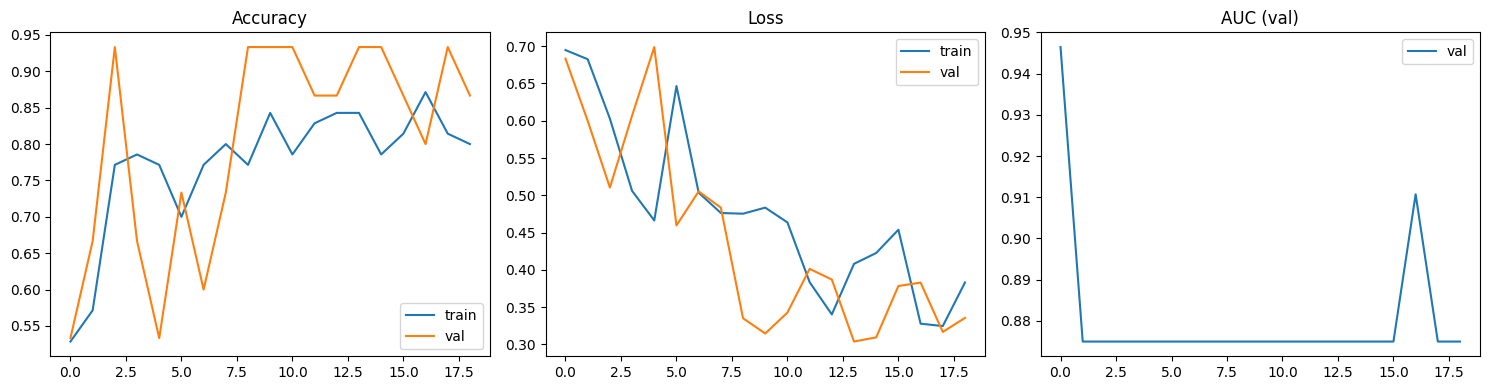

In [11]:
class IDC_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x).squeeze(1)

model = IDC_CNN().to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_auc": []}
best_val_loss = float("inf")
patience = 5
patience_counter = 0
best_state = None

for epoch in range(1, EPOCHS + 1):
    # Treino
    model.train()
    train_losses = []
    train_correct = 0
    train_total = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        preds = (torch.sigmoid(logits) >= 0.5).float()
        train_correct += (preds == y_batch).sum().item()
        train_total += y_batch.size(0)

    train_loss = float(np.mean(train_losses))
    train_acc = train_correct / train_total

    # Validação
    model.eval()
    val_losses = []
    val_correct = 0
    val_total = 0
    val_true = []
    val_prob = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            val_losses.append(loss.item())

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()

            val_correct += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)
            val_true.extend(y_batch.cpu().numpy().astype(int))
            val_prob.extend(probs.cpu().numpy())

    val_loss = float(np.mean(val_losses))
    val_acc = val_correct / val_total
    val_auc = roc_auc_score(val_true, val_prob)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_auc={val_auc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping acionado.")
            break

if best_state is not None:
    model.load_state_dict(best_state)

# Curvas de treino
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["train_acc"], label="train")
axes[0].plot(history["val_acc"], label="val")
axes[0].set_title("Accuracy")
axes[0].legend()

axes[1].plot(history["train_loss"], label="train")
axes[1].plot(history["val_loss"], label="val")
axes[1].set_title("Loss")
axes[1].legend()

axes[2].plot(history["val_auc"], label="val")
axes[2].set_title("AUC (val)")
axes[2].legend()

plt.tight_layout()
plt.show()

## 5) Avaliação no conjunto de teste

Nesta etapa usamos apenas o **conjunto de teste** (não visto no treino) para medir generalização.

Teste - Loss: 0.4647
Teste - Accuracy: 0.8667
Teste - AUC: 0.8750

Classification report (teste):
              precision    recall  f1-score   support

negativo (0)       0.88      0.88      0.88         8
positivo (1)       0.86      0.86      0.86         7

    accuracy                           0.87        15
   macro avg       0.87      0.87      0.87        15
weighted avg       0.87      0.87      0.87        15



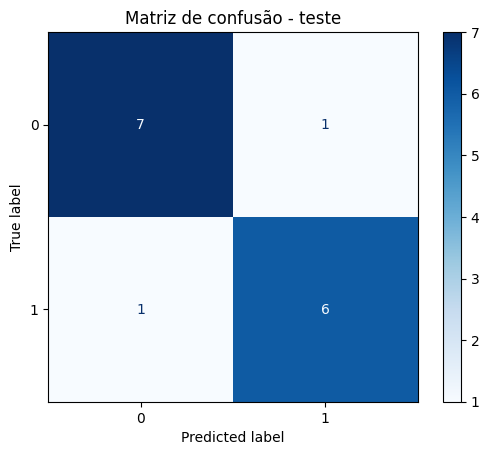

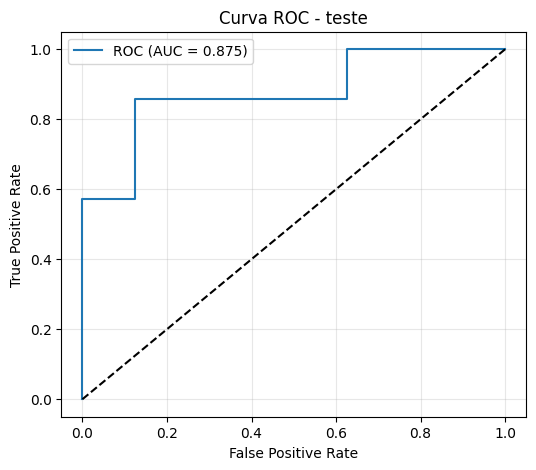

In [12]:
model.eval()
test_losses = []
y_true = []
y_prob = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        probs = torch.sigmoid(logits)

        test_losses.append(loss.item())
        y_true.extend(y_batch.cpu().numpy().astype(int))
        y_prob.extend(probs.cpu().numpy())

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

test_loss = float(np.mean(test_losses))
test_acc = float((y_pred == y_true).mean())
test_auc = roc_auc_score(y_true, y_prob)

print(f"Teste - Loss: {test_loss:.4f}")
print(f"Teste - Accuracy: {test_acc:.4f}")
print(f"Teste - AUC: {test_auc:.4f}")

print("\nClassification report (teste):")
print(classification_report(y_true, y_pred, target_names=["negativo (0)", "positivo (1)"]))

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"]).plot(cmap="Blues")
plt.title("Matriz de confusão - teste")
plt.show()

fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {test_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - teste")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 6) Predições visuais e salvamento do modelo

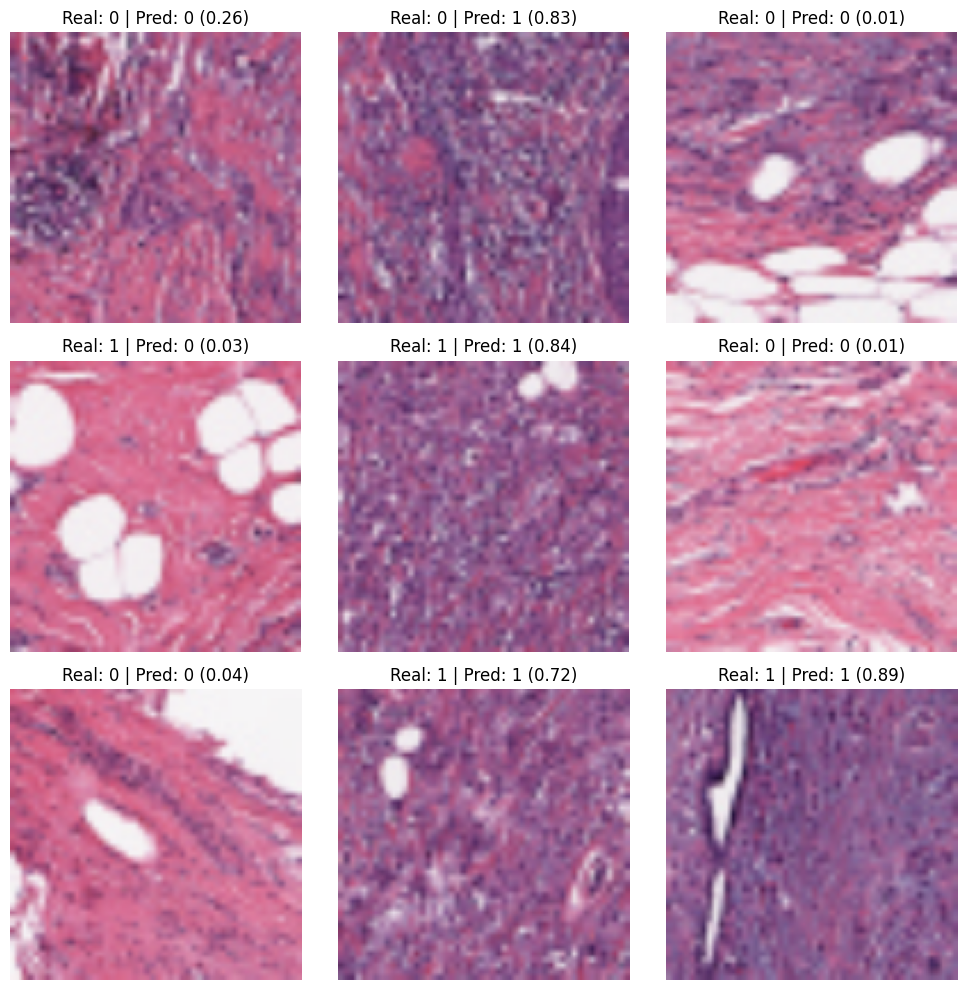

Modelo salvo em: c:\Users\Kelvin\Downloads\Tech-Challenge-FIAP-main\Tech-Challenge-FIAP-main\cnn_idc_model.pth


In [18]:
sample_images, sample_labels = next(iter(test_loader))
model.eval()
with torch.no_grad():
    logits = model(sample_images[:9].to(DEVICE))
    sample_probs = torch.sigmoid(logits).cpu().numpy().ravel()

sample_preds = (sample_probs >= 0.5).astype(int)

plt.figure(figsize=(10, 10))
for i in range(min(9, len(sample_images))):
    ax = plt.subplot(3, 3, i + 1)
    img_np = sample_images[i].permute(1, 2, 0).numpy()
    plt.imshow((img_np * 255).astype("uint8"))
    plt.title(f"Real: {int(sample_labels[i])} | Pred: {sample_preds[i]} ({sample_probs[i]:.2f})")
    plt.axis("off")
plt.tight_layout()
plt.show()

MODEL_PATH = PROJECT_ROOT / "cnn_idc_model.pth"
torch.save(model.state_dict(), MODEL_PATH)
print(f"Modelo salvo em: {MODEL_PATH}")

## 7) Melhorias de avaliação e análise de erro

Para deixar a entrega mais robusta, vamos complementar a avaliação com:

1. ajuste de limiar (threshold) com base na validação;
2. curva Precision-Recall e F1 por threshold;
3. comparação de métricas no threshold padrão (0.50) vs threshold otimizado;
4. inspeção visual dos erros (falsos positivos e falsos negativos).

Melhor threshold (val) por F1: 0.543
F1 na validação: 0.9412


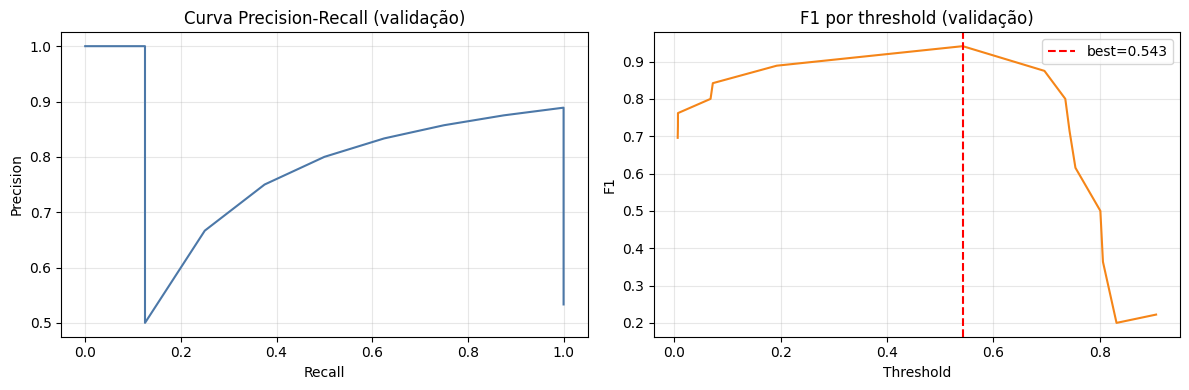

In [17]:
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score

# Probabilidades na validacao para escolher threshold
model.eval()
val_true = []
val_prob = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(DEVICE)
        logits = model(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy()
        val_prob.extend(probs)
        val_true.extend(y_batch.numpy())

val_true = np.array(val_true).astype(int)
val_prob = np.array(val_prob)

prec, rec, thr = precision_recall_curve(val_true, val_prob)
# precision_recall_curve retorna arrays com tamanho diferente para threshold
f1_vals = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-9)
best_idx = int(np.argmax(f1_vals))
best_thr = float(thr[best_idx])

print(f"Melhor threshold (val) por F1: {best_thr:.3f}")
print(f"F1 na validação: {f1_vals[best_idx]:.4f}")

# Curvas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(rec, prec, color="#4C78A8")
axes[0].set_title("Curva Precision-Recall (validação)")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].grid(alpha=0.3)

axes[1].plot(thr, f1_vals, color="#F58518")
axes[1].axvline(best_thr, color="red", linestyle="--", label=f"best={best_thr:.3f}")
axes[1].set_title("F1 por threshold (validação)")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("F1")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

=== Threshold 0.50 (padrão) ===
Precision: 0.8571
Recall:    0.8571
F1-score:  0.8571

=== Threshold otimizado (validação) ===
Threshold: 0.543
Precision: 0.8571
Recall:    0.8571
F1-score:  0.8571


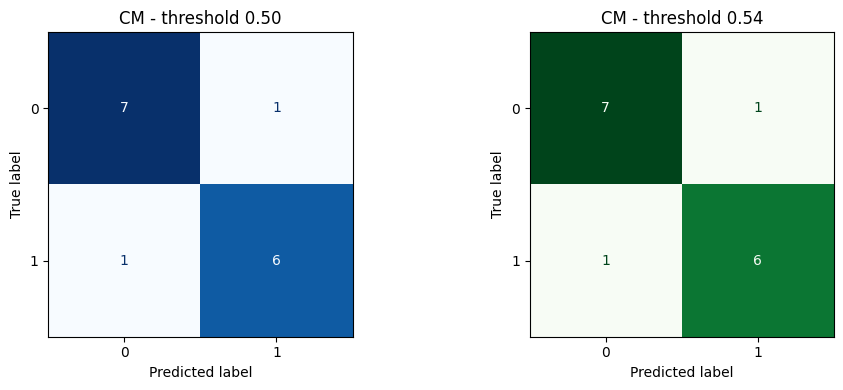

In [15]:
# Compara teste com threshold padrao vs threshold otimizado
pred_default = (y_prob >= 0.5).astype(int)
pred_opt = (y_prob >= best_thr).astype(int)

print("=== Threshold 0.50 (padrão) ===")
print(f"Precision: {precision_score(y_true, pred_default):.4f}")
print(f"Recall:    {recall_score(y_true, pred_default):.4f}")
print(f"F1-score:  {f1_score(y_true, pred_default):.4f}")

print("\n=== Threshold otimizado (validação) ===")
print(f"Threshold: {best_thr:.3f}")
print(f"Precision: {precision_score(y_true, pred_opt):.4f}")
print(f"Recall:    {recall_score(y_true, pred_opt):.4f}")
print(f"F1-score:  {f1_score(y_true, pred_opt):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cm_default = confusion_matrix(y_true, pred_default)
cm_opt = confusion_matrix(y_true, pred_opt)

ConfusionMatrixDisplay(cm_default, display_labels=["0", "1"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("CM - threshold 0.50")

ConfusionMatrixDisplay(cm_opt, display_labels=["0", "1"]).plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title(f"CM - threshold {best_thr:.2f}")

plt.tight_layout()
plt.show()

Total erros (threshold=0.543): 2
Falsos positivos: 1
Falsos negativos: 1


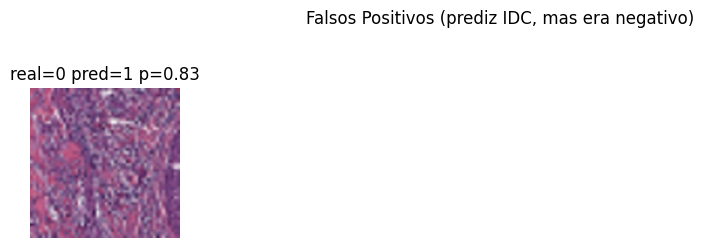

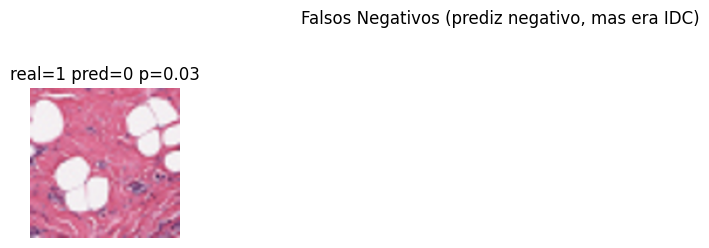

In [16]:
# Inspecao dos erros: exemplos de FP e FN
mis_idx = np.where(pred_opt != y_true)[0]
fp_idx = [i for i in mis_idx if y_true[i] == 0 and pred_opt[i] == 1][:6]
fn_idx = [i for i in mis_idx if y_true[i] == 1 and pred_opt[i] == 0][:6]

print(f"Total erros (threshold={best_thr:.3f}): {len(mis_idx)}")
print(f"Falsos positivos: {len([i for i in mis_idx if y_true[i]==0 and pred_opt[i]==1])}")
print(f"Falsos negativos: {len([i for i in mis_idx if y_true[i]==1 and pred_opt[i]==0])}")

def plot_error_examples(indices, title):
    if len(indices) == 0:
        print(f"Sem exemplos para: {title}")
        return
    plt.figure(figsize=(12, 4))
    for j, i in enumerate(indices):
        img = Image.open(X_test[i]).convert("RGB").resize(IMG_SIZE)
        ax = plt.subplot(2, 3, j + 1)
        plt.imshow(img)
        plt.title(f"real={y_true[i]} pred={pred_opt[i]} p={y_prob[i]:.2f}")
        plt.axis("off")
    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

plot_error_examples(fp_idx, "Falsos Positivos (prediz IDC, mas era negativo)")
plot_error_examples(fn_idx, "Falsos Negativos (prediz negativo, mas era IDC)")

## 8) Conclusão técnica do experimento

### Síntese do que foi feito
- Definimos o target clínico (`IDC` ausente/presente).
- Construímos pipeline de visão computacional com PyTorch (EDA, split estratificado, CNN, avaliação e análise de erro).
- Incluímos avaliação por métricas complementares e ajuste de threshold orientado por validação.

### Principais aprendizados
- A análise visual e quantitativa das imagens ajudou a justificar pré-processamento e arquitetura.
- O modelo é capaz de capturar padrões úteis, mas mantém erros relevantes (FP/FN) que precisam de controle.
- Ajuste de threshold muda o equilíbrio entre `precision` e `recall`, ponto-chave para contexto médico.

### Recomendação de uso
Este modelo é apropriado como **suporte à triagem** e priorização de revisão, não como decisão autônoma. A decisão diagnóstica final deve permanecer com o(a) médico(a), integrada ao contexto clínico e outros exames.

## 9) Interpretação sugerida para apresentação

- Se o threshold otimizado aumentar **recall** com pequena perda de precision, pode ser preferível em contexto clínico (reduzir falso negativo).
- Falsos negativos devem ser tratados como risco principal na triagem, com revisão humana obrigatória.
- Os erros visuais ajudam a identificar padrões difíceis (baixo contraste, artefatos, regiões limítrofes), guiando próximas melhorias de dados/modelo.